In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats


In [3]:
df = pd.read_csv('C:/Users/aryam/OneDrive/Desktop/ML/data/data.csv')

In [4]:
df['date'] = pd.to_datetime(df['dateRep'], format='%d/%m/%Y') # Converted date to datetime format

In [5]:
df.set_index('date', inplace=True) # Set date as index

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61900 entries, 2020-12-14 to 2020-03-21
Data columns (total 12 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   dateRep                                                     61900 non-null  object 
 1   day                                                         61900 non-null  int64  
 2   month                                                       61900 non-null  int64  
 3   year                                                        61900 non-null  int64  
 4   cases                                                       61900 non-null  int64  
 5   deaths                                                      61900 non-null  int64  
 6   countriesAndTerritories                                     61900 non-null  object 
 7   geoId                                                       61625 no

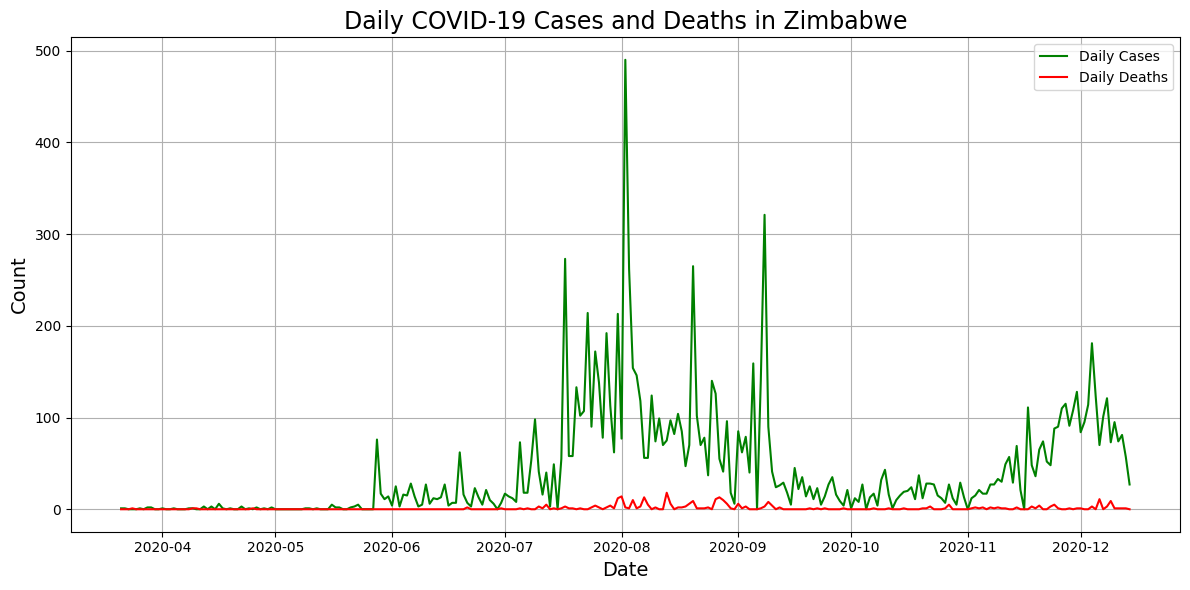

In [ ]:
# 1. Line Plot of COVID 19

Zimbabwe = df[df['countriesAndTerritories'] == 'Zimbabwe']

plt.figure(figsize=(12, 6))
plt.plot(Zimbabwe.index, Zimbabwe['cases'], label='Daily Cases', color='green')
plt.plot(Zimbabwe.index, Zimbabwe['deaths'], label='Daily Deaths', color='red')

plt.title('Daily COVID-19 Cases and Deaths in Zimbabwe', fontsize=17)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



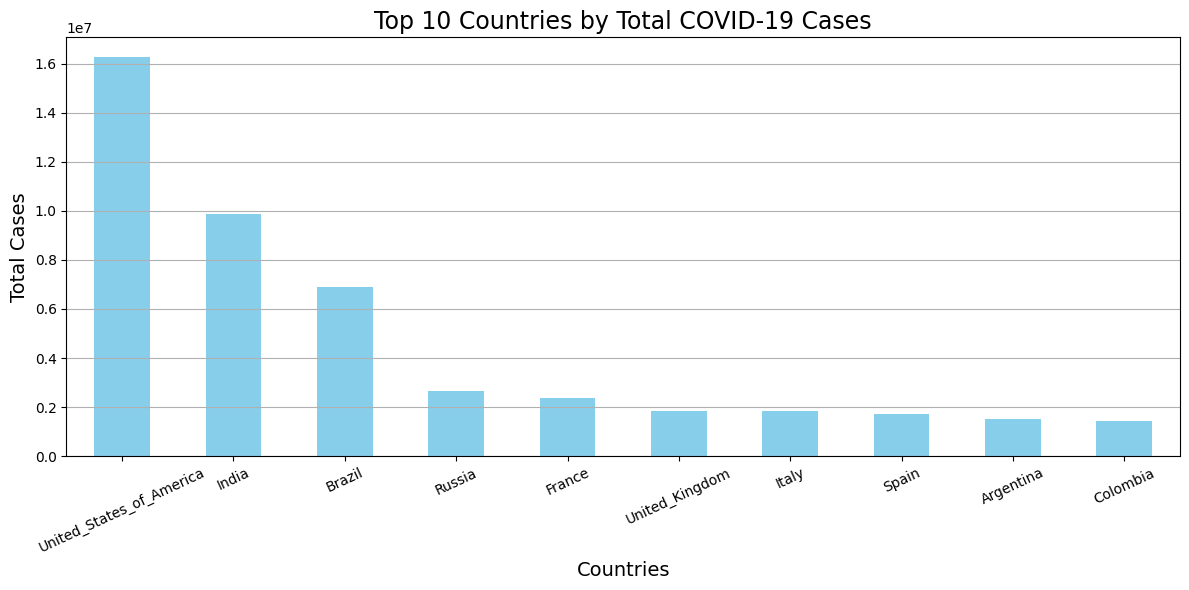

In [ ]:
# 2. Top 10 countries with most cases (Bar Plot)

top_10_countries = df.groupby('countriesAndTerritories')['cases'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
top_10_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Total COVID-19 Cases', fontsize=17)
plt.xlabel('Countries', fontsize=14)
plt.ylabel('Total Cases', fontsize=14)
plt.xticks(rotation=25)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

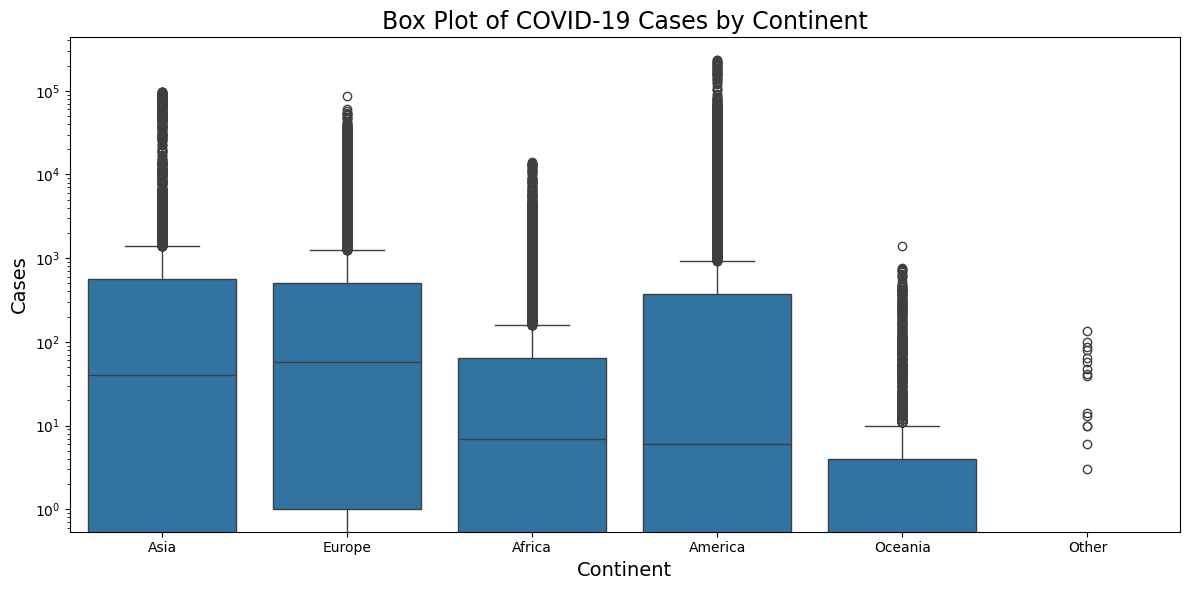

In [7]:
# 3. Compare Continents

plt.figure(figsize=(12, 6))
sns.boxplot(x='continentExp', y='cases', data=df)
plt.title('Box Plot of COVID-19 Cases by Continent', fontsize=17)
plt.xlabel('Continent', fontsize=14)
plt.ylabel('Cases', fontsize=14)
plt.yscale('log')  # Log scale for better visibility
plt.tight_layout()
plt.show()

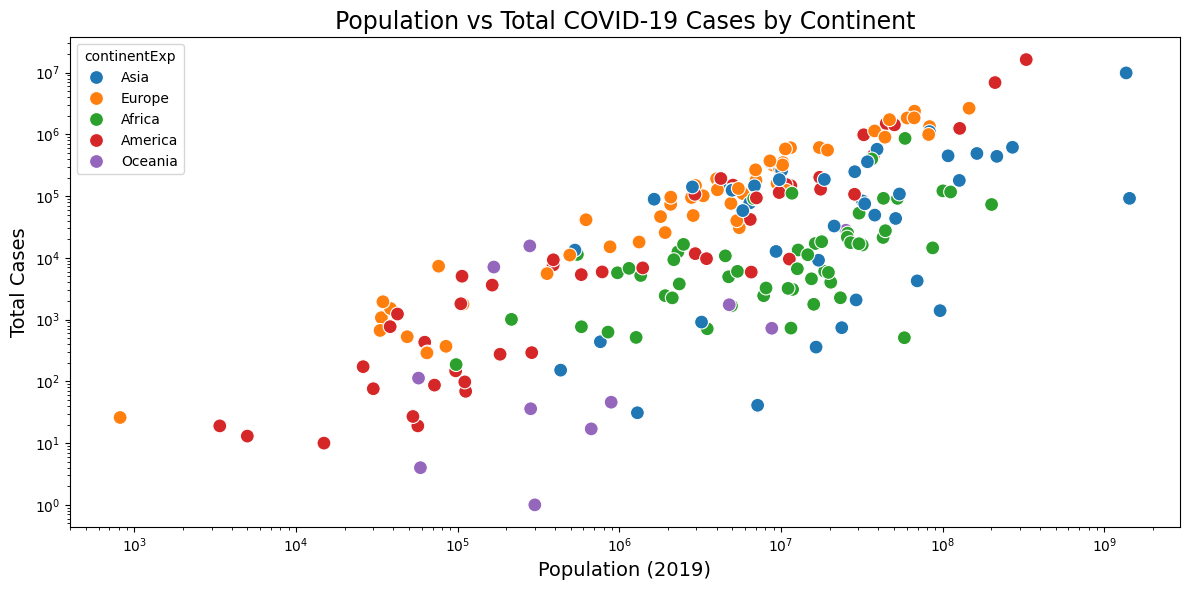

In [35]:
# 4. Population vs Cases (Scatter Plot)

country_stats = df.groupby(['countriesAndTerritories', 'continentExp', 'popData2019']).agg(
                           total_cases=('cases', 'sum'),
                           total_deaths=('deaths', 'sum'),
).reset_index()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='popData2019', y='total_cases', hue='continentExp', data=country_stats, s=100)
plt.title('Population vs Total COVID-19 Cases by Continent', fontsize=17)
plt.xlabel('Population (2019)', fontsize=14)
plt.ylabel('Total Cases', fontsize=14) 
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.show()

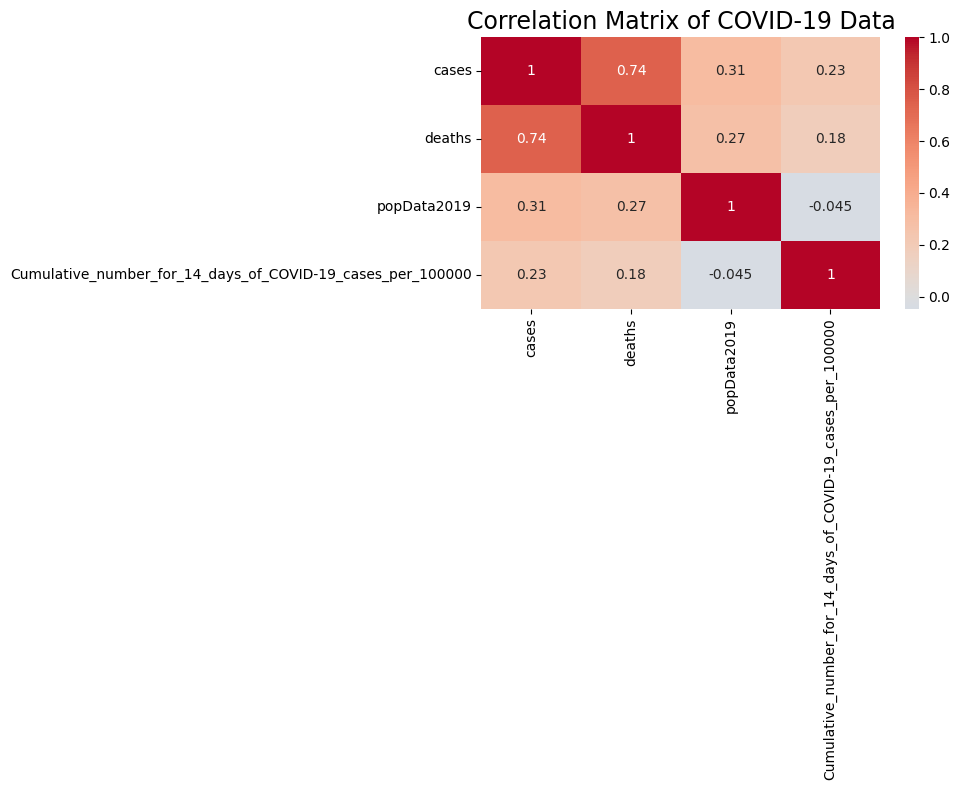

In [45]:
# 5.Heatmap of Correlation Matrix

numeric_cols = df[['cases', 'deaths', 'popData2019', 'Cumulative_number_for_14_days_of_COVID-19_cases_per_100000',]]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of COVID-19 Data', fontsize=17)
plt.tight_layout()
plt.show()

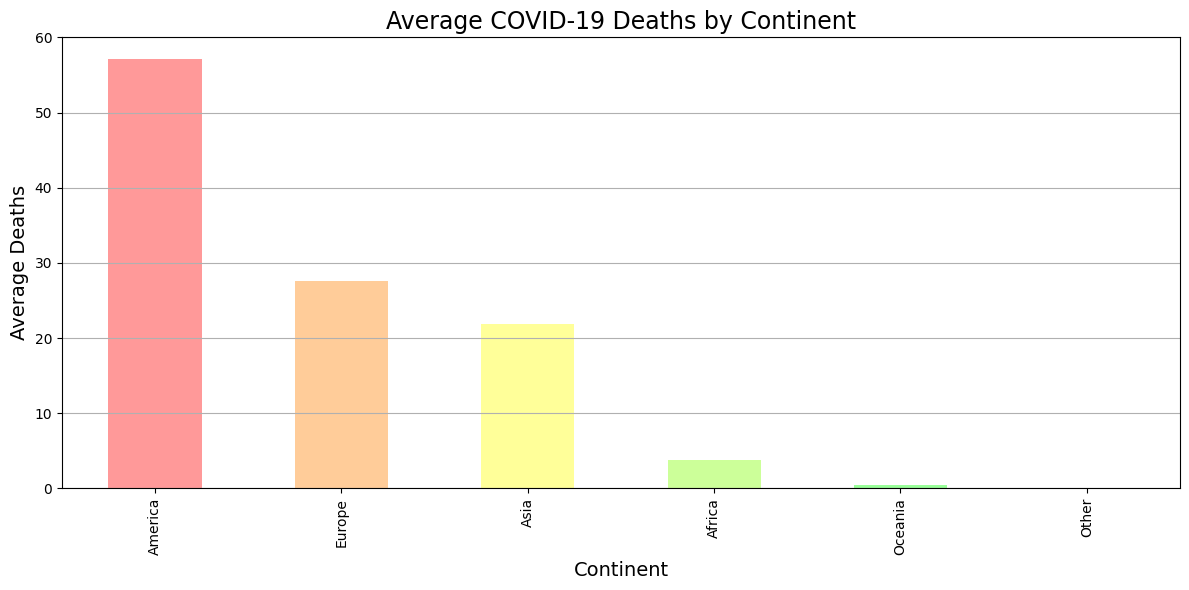

In [47]:
# 6. Custom Color Palette Plot

avg_deaths = df.groupby('continentExp')['deaths'].mean().sort_values(ascending=False)
custom_palette = ['#FF9999', '#FFCC99', '#FFFF99', '#CCFF99', '#99FF99', '#99FFFF']

plt.figure(figsize=(12, 6))
avg_deaths.plot(kind='bar', color=custom_palette)
plt.title('Average COVID-19 Deaths by Continent', fontsize=17)
plt.xlabel('Continent', fontsize=14)
plt.ylabel('Average Deaths', fontsize=14)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# 7. T-test using SciPy

asia_data = df[df['continentExp'] == 'Asia']['Cumulative_number_for_14_days_of_COVID-19_cases_per_100000'].dropna()
europe_data = df[df['continentExp'] == 'Europe']['Cumulative_number_for_14_days_of_COVID-19_cases_per_100000'].dropna()

t_stat, p_value = stats.ttest_ind(asia_data, europe_data, equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("The difference in 14-day cumulative case rates between Asia and Europe is statistically significant.")
else:
    print("The difference in 14-day cumulative case rates between Asia and Europe is not statistically significant.")

T-statistic: -37.90
P-value: 0.0000
The difference in 14-day cumulative case rates between Asia and Europe is statistically significant.


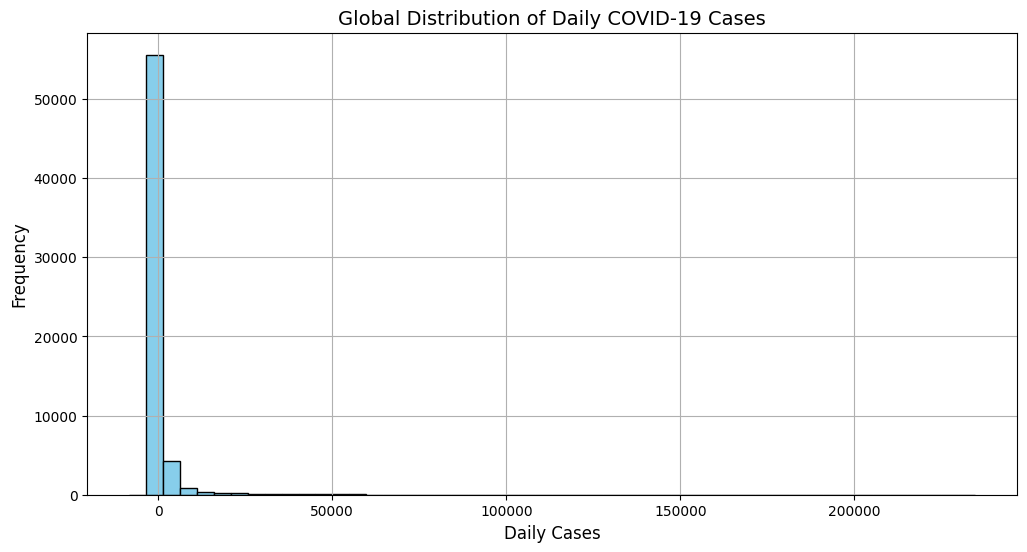

In [53]:
# 8. Histogram of Daily Cases

plt.figure(figsize=(12, 6))
plt.hist(df['cases'], bins=50, color='skyblue', edgecolor='black')
plt.title('Global Distribution of Daily COVID-19 Cases', fontsize=14)
plt.xlabel('Daily Cases', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()

C:\Users\aryam\AppData\Local\Temp\ipykernel_30344\586204238.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_deaths = df['deaths'].resample('M').mean()


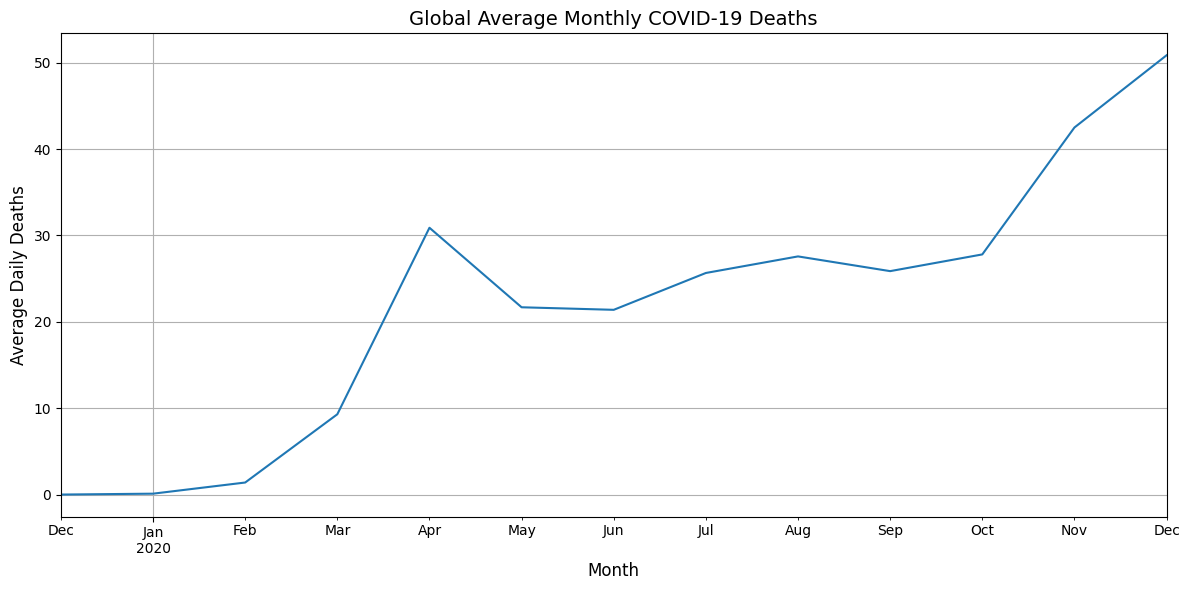

In [54]:
# 9. Trend of Deaths Over Months (Group by Months)

monthly_deaths = df['deaths'].resample('M').mean()

plt.figure(figsize=(12, 6))
monthly_deaths.plot()
plt.title('Global Average Monthly COVID-19 Deaths', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Daily Deaths', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

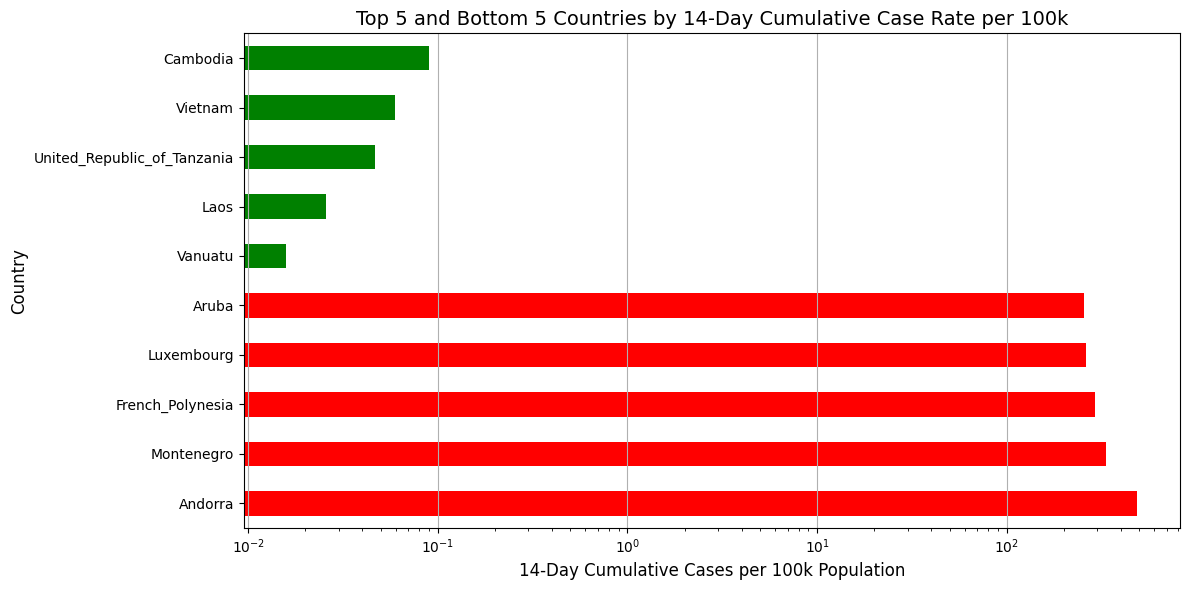

In [58]:
# 10. Cumulative Case Rate: Top vs Bottom Countries

case_rate = df.groupby('countriesAndTerritories')['Cumulative_number_for_14_days_of_COVID-19_cases_per_100000'].mean()

top_5 = case_rate.nlargest(5)
bottom_5 = case_rate.nsmallest(5)
combined = pd.concat([top_5, bottom_5])

plt.figure(figsize=(12, 6))
combined.plot(kind='barh', color=['red']*5 + ['green']*5)
plt.title('Top 5 and Bottom 5 Countries by 14-Day Cumulative Case Rate per 100k', fontsize=14)
plt.xlabel('14-Day Cumulative Cases per 100k Population', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x')
plt.xscale('log')  
plt.tight_layout()
plt.show()